In [3]:
# Coffee Shop Sales – Exploratory Data Analysis

#This notebook explores sales patterns, customer preferences, and revenue trends using transactional data from a coffee shop. 
#The analysis focuses on temporal trends and product-level performance to support operational decision-making.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Overview

df= pd.read_csv("C:\\Users\Admin\OneDrive\Desktop\Coffe_sales.csv")
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,3/1/2024,15:50.5
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,19:22.5
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,20:18.1
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,3/1/2024,46:33.0
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,3/1/2024,48:14.6


In [2]:
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,3/23/2025,34:54.9
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,3/23/2025,43:37.4
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,3/23/2025,44:16.9
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,3/23/2025,47:28.7
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,3/23/2025,11:38.6


In [3]:
## Data Cleaning and Validation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [4]:
df.describe(include='all')

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
count,3547.000000,3547,3547.000000,3547,3547,3547,3547,3547.000000,3547.000000,3547,3547
unique,NaN,1,NaN,8,3,7,12,NaN,NaN,381,3374
top,NaN,card,NaN,Americano with Milk,Afternoon,Tue,Mar,NaN,NaN,10/11/2024,08:18.8
freq,NaN,3547,NaN,809,1205,572,494,NaN,NaN,26,3
mean,14.185791,NaN,31.645216,NaN,NaN,NaN,NaN,3.845785,6.453905,NaN,NaN
std,4.234010,NaN,4.877754,NaN,NaN,NaN,NaN,1.971501,3.500754,NaN,NaN
min,6.000000,NaN,18.120000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,10.000000,NaN,27.920000,NaN,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,14.000000,NaN,32.820000,NaN,NaN,NaN,NaN,4.000000,7.000000,NaN,NaN
75%,18.000000,NaN,35.760000,NaN,NaN,NaN,NaN,6.000000,10.000000,NaN,NaN


In [5]:
df.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# display the list of available coffee
print('The list of available coffee : ')
for num,coffee in enumerate(df['coffee_name'].unique(),1):
    print('{} - {}'.format(num,coffee))

The list of available coffee : 
1 - Latte
2 - Hot Chocolate
3 - Americano
4 - Americano with Milk
5 - Cocoa
6 - Cortado
7 - Espresso
8 - Cappuccino


In [4]:
# display the average purchase $
mean=df['money'].mean()
print('The average purchase is :${: .2f} '.format(mean))

The average purchase is :$ 31.65 


In [5]:
# price of coffee
# As the most expensive coffee and the cheapest coffee is   


x=df.loc[df['money'].idxmax(),'coffee_name']
y=df['money'].max()

z=df.loc[df['money'].idxmin(),'coffee_name']
h=df['money'].min()

print('The most expensive coffee is :',x,', with price: ',y,'$\n')
print('The cheapest coffee is :',z,', with price: ',h,'$')

The most expensive coffee is : Latte , with price:  38.7 $

The cheapest coffee is : Espresso , with price:  18.12 $


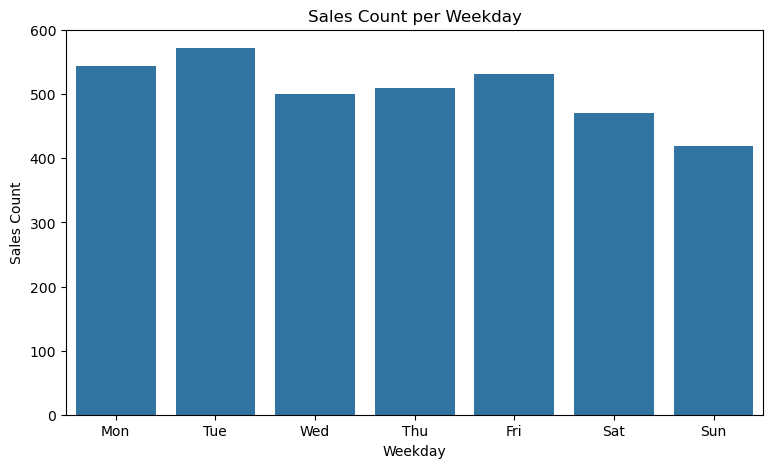

The busiest day of the week is: Tue
The slowest day of the week is: Sun


In [6]:
## Sales Analysis by Weekday

weekday_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sales_day = df['Weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(9,5))
sns.barplot(x=sales_day.index, y=sales_day.values)
plt.title("Sales Count per Weekday")
plt.xlabel("Weekday")
plt.ylabel("Sales Count")
plt.show()

busiest = sales_day.idxmax()
slowest = sales_day.idxmin()

print(f"The busiest day of the week is: {busiest}")
print(f"The slowest day of the week is: {slowest}")



In [11]:
print('Total number of sales by coffee name :')
df['coffee_name'].value_counts()

Total number of sales by coffee name :


coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

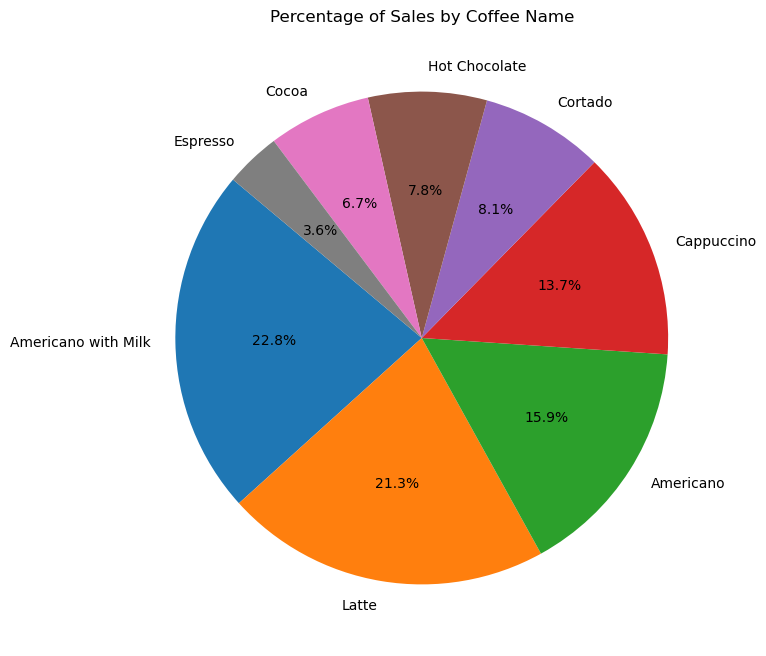

The most popular coffee is: Americano with Milk
The least popular coffee is: Espresso


In [12]:
## Sales Analysis by Coffee Type

sales_coffee = df['coffee_name'].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
sales_coffee.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Sales by Coffee Name')
plt.show()


most_popular = sales_coffee.idxmax()
least_popular = sales_coffee.idxmin()

print(f"The most popular coffee is: {most_popular}")
print(f"The least popular coffee is: {least_popular}")

In [13]:
# Count sales by coffee and time
df_group = df.groupby(['coffee_name', 'Time_of_Day']).size().unstack(fill_value=0)

df_group.loc['Total'] = df_group.sum()

df_group


Time_of_Day,Afternoon,Morning,Night
coffee_name,,,
Americano,233,219,112
Americano with Milk,239,331,239
Cappuccino,164,122,200
Cocoa,75,58,106
Cortado,88,143,56
Espresso,56,44,29
Hot Chocolate,80,49,147
Latte,270,215,272
Total,1205,1181,1161


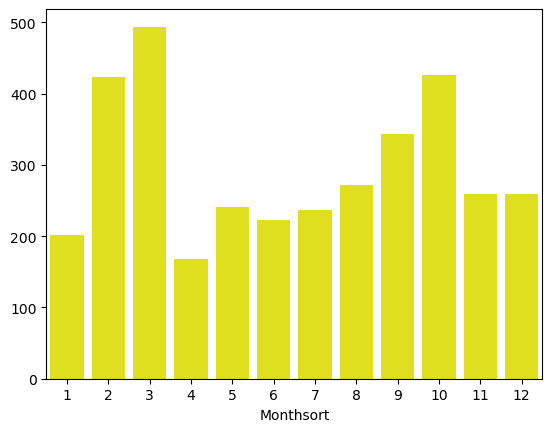

In [15]:
## Monthly Sales Trends

sales_per_month = df['Monthsort'].value_counts().sort_index()
sns.barplot(x=sales_per_month.index, y=sales_per_month.values,color="yellow")
plt.show()

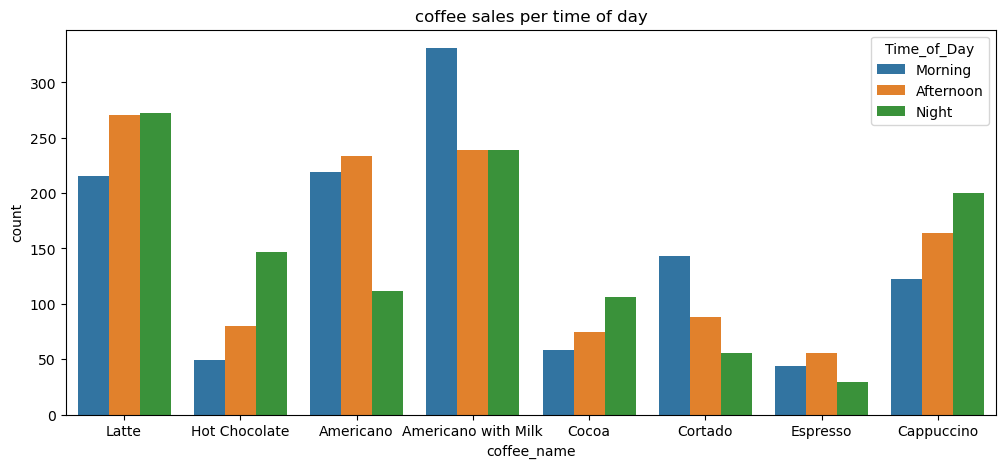

In [16]:
## Time of Day Analysis

plt.figure(figsize=(12,5))
plt.title('coffee sales per time of day')
sns.countplot(data=df,x='coffee_name',hue='Time_of_Day')
plt.show()

In [17]:
#Best-selling coffee
best_selling_coffee = df['coffee_name'].value_counts().idxmax()
best_selling_count = df['coffee_name'].value_counts().max()
print(f"Best-selling coffee: {best_selling_coffee} ({best_selling_count} sales)")

Best-selling coffee: Americano with Milk (809 sales)


In [18]:
## Revenue Analysis
#Total revenue for each coffee type
revenue_by_coffee = df.groupby('coffee_name')['money'].sum().round(2)
print("\nTotal revenue by coffee type ($):")
print(revenue_by_coffee)


Total revenue by coffee type ($):
coffee_name
Americano              14650.26
Americano with Milk    24751.12
Cappuccino             17439.14
Cocoa                   8521.16
Cortado                 7384.86
Espresso                2690.28
Hot Chocolate           9933.46
Latte                  26875.30
Name: money, dtype: float64


In [19]:
## Key Insights and Conclusion
#Busiest hour of the day for coffee sales
busiest_hour = df['hour_of_day'].value_counts().idxmax()
busiest_hour_count = df['hour_of_day'].value_counts().max()
print(f"\nBusiest hour: {int(busiest_hour)}:00 ({busiest_hour_count} sales)")


Busiest hour: 10:00 (328 sales)


In [20]:
#Day of the week with the highest sales
highest_sales_day = df['Weekday'].value_counts().idxmax()
highest_sales_count = df['Weekday'].value_counts().max()
print(f"\nDay with highest sales: {highest_sales_day} ({highest_sales_count} sales)")


Day with highest sales: Tue (572 sales)


In [21]:
#Seasonal trend in coffee sales (by month)
monthly_sales = df.groupby('Month_name').size()
print("\nMonthly sales count:")
print(monthly_sales)


Monthly sales count:
Month_name
Apr    168
Aug    272
Dec    259
Feb    423
Jan    201
Jul    237
Jun    223
Mar    494
May    241
Nov    259
Oct    426
Sep    344
dtype: int64


 Time of Day vs Coffee Type Analysis:
Percentage distribution of coffee types by time of day:
coffee_name  Americano  Americano with Milk  Cappuccino  Cocoa  Cortado  \
Time_of_Day                                                               
Afternoon        19.34                19.83       13.61   6.22     7.30   
Morning          18.54                28.03       10.33   4.91    12.11   
Night             9.65                20.59       17.23   9.13     4.82   

coffee_name  Espresso  Hot Chocolate  Latte  
Time_of_Day                                  
Afternoon        4.65           6.64  22.41  
Morning          3.73           4.15  18.20  
Night            2.50          12.66  23.43  


<Figure size 1400x800 with 0 Axes>

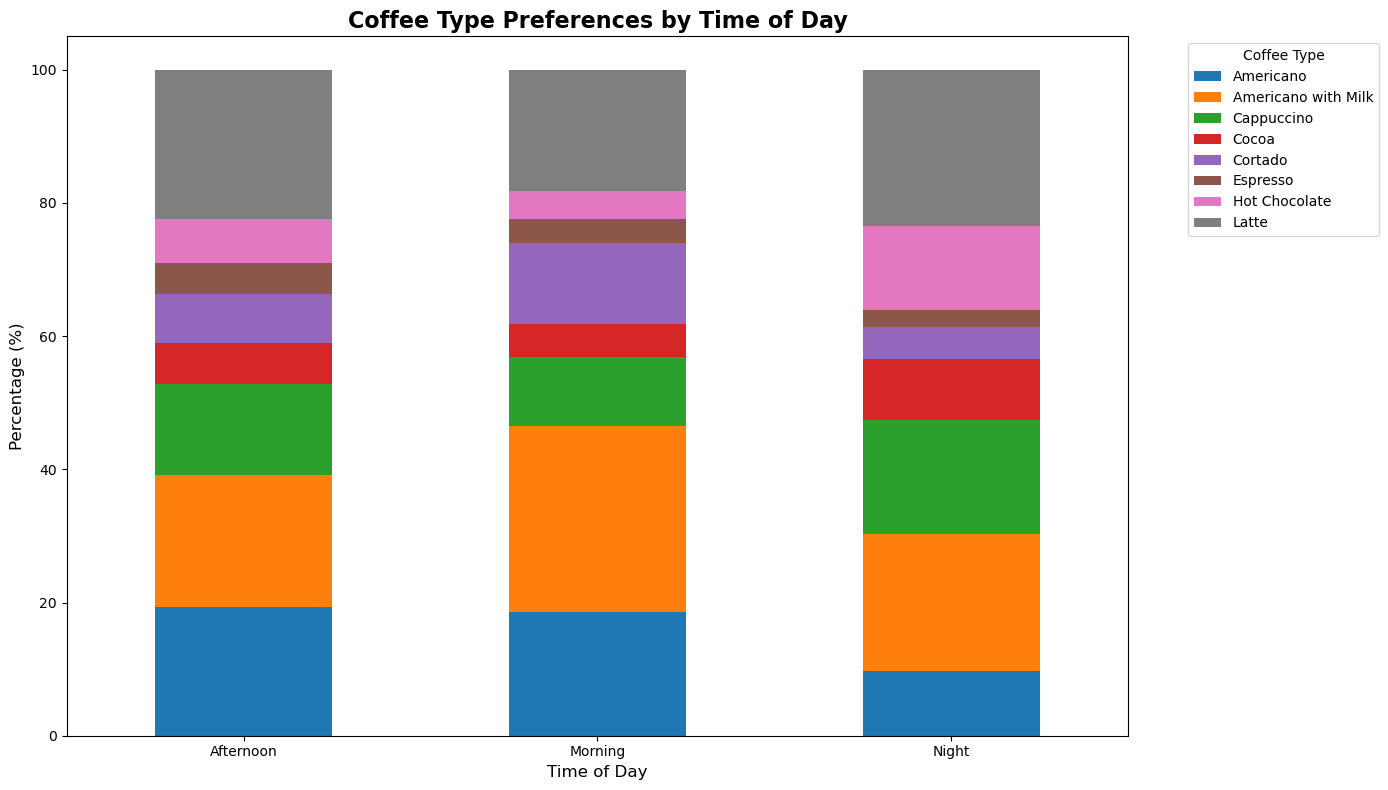

In [22]:
# 1. Relationship between time of day and type of coffee purchased
print(" Time of Day vs Coffee Type Analysis:")
time_coffee_ct = pd.crosstab(df['Time_of_Day'], df['coffee_name'], normalize='index') * 100
print("Percentage distribution of coffee types by time of day:")
print(time_coffee_ct.round(2))

plt.figure(figsize=(14, 8))
time_coffee_ct.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Coffee Type Preferences by Time of Day', fontsize=16, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Coffee Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()